# QFI Diagnostics for Quantum Machine Learning

* QFI Diagnostics for Quantum Machine Learning (NISQ 2026)
* Диагностика квантовых нейросетей через квантовую информацию Фишера.
* От toy-модели до NISQ-лимита — на датасете типичного для ML размера.
* Метрики адаптированы для ML-аудитории.
* Август 2026. Симулятор: PennyLane default.qubit.

* **Проверено на: pennylane==0.45.1, numpy==2.2.6, matplotlib==3.10.9, scikit-learn==1.9.0**

1. Датасет make_moons (типичная для ML форма и размер выборки), чтобы EDA-разведка и корреляция с SVM были содержательными, а не иллюстративными "на пальцах".
2. Чистое сравнение ГЛУБИНЫ схемы при ФИКСИРОВАННОМ числе кубитов (run_depth_scan) — изолирует эффект количества слоев от эффекта количества кубитов.
3. Классическая SVM + корреляция QFI-чувствительности с расстоянием до границы классификатора (run_svm_correlation).
4. "Квантовая разведка" датасета — scatter с точками, раскрашенными по чувствительности QFI, поверх границы SVM.

* Общая канва (Toy / Standard NISQ / Deep NISQ, четырtхпанельная фигура)

In [1]:
import pennylane as qml
import pennylane.numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import os

from sklearn.datasets import make_moons
from sklearn.svm import SVC

mpl.rcParams.update({
    "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 8, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "-",
    "axes.facecolor": "#FAFAFA", "figure.facecolor": "white",
    "axes.edgecolor": "#333333", "text.color": "#333333",
    "xtick.color": "#555555", "ytick.color": "#555555",
    "savefig.bbox": "tight", "savefig.pad_inches": 0.15,
})

C = {
    "toy": "#2E86AB", "std": "#A23B72", "deep": "#F18F01",
    "ry": "#F4A261", "rz": "#E76F51", "accent": "#264653",
    "ok": "#2A9D8F", "warn": "#E9C46A", "bad": "#E76F51",
    "layer1": "#2E86AB", "layer2": "#A23B72",
    "layer3": "#F18F01", "layer4": "#6A994E",
    "class0": "#2E86AB", "class1": "#F18F01",
}

## 1. ДАТАСЕТ: типичный для ML размер

In [2]:
def make_dataset(n_samples=24, noise=0.15, seed=42):
    """
    make_moons — два нелинейно разделимых полумесяца, 2 признака.
    Масштабируем в [0, pi] под угловое кодирование (angle encoding).
    n_samples=24 — компромисс: достаточно для содержательной EDA-
    разведки и корреляции с SVM, но все ещё быстро считается на CPU.
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    X_scaled = (X - X_min) / (X_max - X_min) * np.pi
    return pnp.array(X_scaled, requires_grad=False), y, X  # X — для отрисовки в исходном масштабе

## 2. КВАНТОВАЯ СХЕМА: Hardware-Efficient Ansatz + Data Re-uploading

In [3]:
def make_circuit(n_qubits: int, n_layers: int):
    """
    Стандартный HEA с повторным кодированием данных.
    Кодирование — НЕобучаемое (requires_grad=False), поэтому в QFI
    попадают только вариационные параметры theta.
    """
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(theta, x):
        th = theta.reshape(n_layers, n_qubits, 2)
        for l in range(n_layers):
            # --- Data re-uploading (необучаемое) ---
            for q in range(n_qubits):
                qml.RY(x[q % len(x)], wires=q)
            # --- Вариационный блок ---
            for q in range(n_qubits):
                qml.RY(th[l, q, 0], wires=q)
                qml.RZ(th[l, q, 1], wires=q)
            for q in range(n_qubits - 1):
                qml.CNOT(wires=[q, q + 1])
        return qml.expval(qml.PauliZ(0))

    return circuit


def param_labels(n_qubits, n_layers):
    return [f"L{l+1}·Q{q}·{g}"
            for l in range(n_layers)
            for q in range(n_qubits)
            for g in ("RY", "RZ")]

## 3. МЕТРИКИ ДЛЯ ML-ДИАГНОСТИКИ

In [4]:
def compute_ml_metrics(qfim, n_qubits, n_layers):
    n_params = n_layers * n_qubits * 2
    sens = np.diag(qfim)
    eigvals = np.linalg.eigvalsh(qfim)[::-1]

    eff_dim = int(np.sum(eigvals > 1e-6))
    eff_dim_ratio = eff_dim / n_params

    mean_sens = float(np.mean(sens))
    max_sens = float(np.max(sens))

    spectral_gap = float(eigvals[0] / eigvals[eff_dim - 1]) if eff_dim > 1 else np.inf

    pr = float(np.sum(eigvals) ** 2 / np.sum(eigvals ** 2))
    pr_ratio = pr / n_params

    inter_vals = []
    for i in range(n_params):
        li = i // (n_qubits * 2)
        for j in range(i + 1, n_params):
            lj = j // (n_qubits * 2)
            if li != lj:
                inter_vals.append(abs(qfim[i, j]))
    cross_layer_corr = float(np.mean(inter_vals)) if inter_vals else 0.0

    cond_num = float(eigvals[0] / eigvals[-1]) if eigvals[-1] > 1e-12 else np.inf

    bp_risk = "LOW"
    if spectral_gap < 5 or pr_ratio > 0.9:
        bp_risk = "CRITICAL"
    elif spectral_gap < 10 or pr_ratio > 0.8:
        bp_risk = "HIGH"
    elif spectral_gap < 20 or pr_ratio > 0.7:
        bp_risk = "MEDIUM"

    return {
        "n_params": n_params, "eff_dim": eff_dim, "eff_dim_ratio": eff_dim_ratio,
        "mean_sens": mean_sens, "max_sens": max_sens,
        "spectral_gap": spectral_gap, "participation_ratio": pr,
        "pr_ratio": pr_ratio, "cross_layer_corr": cross_layer_corr,
        "condition_number": cond_num, "bp_risk": bp_risk,
        "sens": sens, "eigvals": eigvals, "qfim": qfim,
    }

## 4. ОСНОВНОЙ ЭКСПЕРИМЕНТ: Toy / Standard NISQ / Deep NISQ

In [5]:
def get_qfi_fn(circuit):
    return qml.gradients.quantum_fisher(circuit)


def extract_qfim(qfi_result):
    """
    PennyLane может вернуть QFIM либо напрямую, либо в виде tuple —
    например, если у circuit больше одного trainable-аргумента (tuple
    приходит по одному элементу на каждый обучаемый параметр функции).
    В этом скрипте x всегда requires_grad=False, поэтому обучаемый
    аргумент только один (theta) и tuple не возникает — но код защищен
    на случай, если убрать requires_grad=False
    у датасета: тогда вместо непонятного TypeError будет явно взят
    первый элемент (QFIM по theta).
    """
    if isinstance(qfi_result, tuple):
        return qfi_result[0]
    return qfi_result


def run_experiment(name, n_qubits, n_layers, X_scaled, seed=42):
    n_params = n_layers * n_qubits * 2
    rng = pnp.random.default_rng(seed)
    theta = pnp.array(rng.uniform(0, 2 * pnp.pi, n_params), requires_grad=True)
    circuit = make_circuit(n_qubits, n_layers)
    qfi_fn = get_qfi_fn(circuit)

    # Усреднение по датасету — критично для ML
    qfim = pnp.mean(
        pnp.stack([extract_qfim(qfi_fn(theta, x)) for x in X_scaled]), axis=0
    )
    qfim = np.array(qfim)

    metrics = compute_ml_metrics(qfim, n_qubits, n_layers)
    metrics["name"] = name
    metrics["n_qubits"] = n_qubits
    metrics["n_layers"] = n_layers
    metrics["labels"] = param_labels(n_qubits, n_layers)
    return metrics

## 5. ЧЕСТНОЕ СРАВНЕНИЕ ГЛУБИНЫ: фиксированное число кубитов

In [6]:
def run_depth_scan(n_qubits, layer_list, X_scaled, seed=42):
    """
    В отличие от сравнения Toy/Standard/Deep (где меняются И число
    кубитов, И число слоев одновременно), здесь кубиты зафиксированы —
    это изолирует именно эффект глубины, а не архитектуры в целом.
    Отвечает на вопрос "сколько слоев реально нужно?" без примеси
    эффекта от увеличения ширины схемы.
    """
    results = []
    for n_layers in layer_list:
        m = run_experiment(f"{n_layers}L", n_qubits, n_layers, X_scaled, seed=seed)
        results.append(m)
    return results


def print_depth_scan_table(depth_results, n_qubits):
    print("\n" + "="*75)
    print(f"СКАНИРОВАНИЕ ГЛУБИНЫ (фиксировано: {n_qubits} кубита)")
    print("="*75)
    print(f"| Слоёв | Параметров | Средняя чувствительность | Прирост к пред. |")
    print(f"|---|---|---|---|")
    prev = None
    for r in depth_results:
        gain = "—" if prev is None else f"{(r['mean_sens'] - prev) / prev:+.1%}"
        print(f"| {r['n_layers']} | {r['n_params']} | {r['mean_sens']:.3f} | {gain} |")
        prev = r["mean_sens"]

## 6. КЛАССИЧЕСКАЯ SVM + КОРРЕЛЯЦИЯ С QFI-ЧУВСТВИТЕЛЬНОСТЬЮ

In [7]:
def run_svm_correlation(X_scaled, y, n_qubits, n_layers, seed=42):
    """
    1. Обучаем классический SVM (RBF-ядро) на том же датасете.
    2. Для каждой точки считаем "индекс напряжённости" — след QFI,
       деленный на число параметров (та же нормировка, что и в
       compute_ml_metrics).
    3. Считаем корреляцию Пирсона между |decision_function| SVM
       (расстояние до границы) и QFI-чувствительностью точки.

    Слабая корреляция — ожидаемый и содержательный результат: QFI
    измеряет чувствительность именно КВАНТОВОЙ схемы на случайных
    весах, а не классическую сложность точки.
    """
    X_np = np.array(X_scaled)
    svm = SVC(kernel="rbf", C=1.0)
    svm.fit(X_np, y)
    svm_distance = np.abs(svm.decision_function(X_np))

    n_params = n_layers * n_qubits * 2
    rng = pnp.random.default_rng(seed)
    theta = pnp.array(rng.uniform(0, 2 * pnp.pi, n_params), requires_grad=True)
    circuit = make_circuit(n_qubits, n_layers)
    qfi_fn = get_qfi_fn(circuit)

    per_point_sens = np.array([
        float(np.mean(np.diag(np.array(extract_qfim(qfi_fn(theta, x))))))
        for x in X_scaled
    ])

    correlation = float(np.corrcoef(svm_distance, per_point_sens)[0, 1])

    return {
        "svm": svm, "svm_distance": svm_distance,
        "per_point_sens": per_point_sens, "correlation": correlation,
        "n_qubits": n_qubits, "n_layers": n_layers,
    }

## 7. ВИЗУАЛИЗАЦИЯ: основная фигура (Toy / Standard / Deep)

In [8]:
def plot_article_figure(results, save_path="figures/qfi_ml_diagnostics.png"):
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle("QFI-диагностика квантовой нейросети: от toy-модели до NISQ-лимита",
                 fontsize=13, fontweight='bold', y=0.98)

    # ── (0,0): Нормализованные спектры ─────────────────────────
    ax = axes[0, 0]
    for res, color, marker in zip(results, [C["toy"], C["std"], C["deep"]], ['o', 's', '^']):
        ev = res["eigvals"]
        ev_norm = ev / ev[0]
        x = np.arange(1, len(ev) + 1)
        ax.semilogy(x, ev_norm, marker=marker, color=color, markersize=4,
                    linewidth=1.5, label=f'{res["name"]}: $d_{{eff}}$={res["eff_dim"]}/{res["n_params"]}')
        ax.axvline(res["eff_dim"] + 0.5, color=color, linestyle='--', alpha=0.4, linewidth=1.2)
    ax.axhline(1e-6 / results[0]["eigvals"][0], color='#888888', linestyle=':', linewidth=1, label='Порог значимости')
    ax.set_xlabel("Номер собственного значения")
    ax.set_ylabel("Нормализованное собственное значение (log)")
    ax.set_title("Спектр QFI: где заканчивается полезная размерность")
    ax.legend(loc='lower left', framealpha=0.9)
    ax.set_xlim(0.5, max(r["n_params"] for r in results) + 0.5)

    # ── (0,1): ML-метрики сравнение ────────────────────────────
    # ИСПРАВЛЕНО: легенда вынесена НАД графиком горизонтально,
    # чтобы не перекрывать подписи баров (в т.ч. у Deep NISQ).
    ax = axes[0, 1]
    names = [r["name"] for r in results]
    x = np.arange(len(names))
    w = 0.25
    vals = [r["eff_dim_ratio"] for r in results]
    bars1 = ax.bar(x - w, vals, w, color=C["toy"], alpha=0.85, label="$d_{eff}$ / $N_{params}$")
    vals = [r["pr_ratio"] for r in results]
    bars2 = ax.bar(x, vals, w, color=C["std"], alpha=0.85, label="PR / $N_{params}$")
    vals = [1 - r["cross_layer_corr"] for r in results]
    bars3 = ax.bar(x + w, vals, w, color=C["deep"], alpha=0.85, label="Layer modularity")
    ax.set_ylabel("Нормализованная метрика")
    ax.set_title("ML-метрики: эффективность архитектуры")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.1)
    # ИСПРАВЛЕНО (2-я итерация): легенда сверху создавала асимметрию по
    # высоте между панелями 2x2 (у этой панели заголовок отодвигался от
    # графика сильнее, чем у остальных трёх). Легенда сбоку решает обе
    # проблемы разом: не перекрывает бары И не сдвигает заголовок.
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
              framealpha=0.9, borderaxespad=0.)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}",
                    ha='center', va='bottom', fontsize=7.5)

    # ── (1,0): Чувствительность параметров (Standard NISQ) ─────
    ax = axes[1, 0]
    r = results[1]  # Standard: 4×3
    sens, labels = r["sens"], r["labels"]
    order = np.argsort(sens)[::-1]
    s_sorted = sens[order]
    l_sorted = [labels[i] for i in order]
    colors = [C[f"layer{int(lbl.split('·')[0][1:])}"] for lbl in l_sorted]
    bars = ax.barh(range(len(s_sorted)), s_sorted, color=colors, edgecolor='white', height=0.65)
    ax.set_yticks(range(len(l_sorted)))
    ylabels = []
    for i, lbl in enumerate(l_sorted):
        if i < 3 or i >= len(l_sorted) - 3 or i % 2 == 0:
            ylabels.append(lbl)
        else:
            ylabels.append("")
    ax.set_yticklabels(ylabels, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("QFI (диагональный элемент)")
    ax.set_title(f'Чувствительность: {r["name"]} ({r["n_params"]} пар.)')
    ax.set_xlim(0, max(s_sorted) * 1.15)
    for i, (bar, val) in enumerate(zip(bars, s_sorted)):
        if i < 6 or i >= len(s_sorted) - 3:
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
                    va='center', ha='left', fontsize=7)
    legend_el = [Line2D([0], [0], marker='s', color='w', markerfacecolor=C[f"layer{i+1}"],
                         markersize=8, label=f"Слой {i+1}") for i in range(r["n_layers"])]
    ax.legend(handles=legend_el, loc='lower right', fontsize=7.5, framealpha=0.9)
    ax.annotate('Примечание: RZ занижены\n(измерение PauliZ не\nчувствительно к Z-вращениям)',
                xy=(0.98, 0.30), xycoords='axes fraction', fontsize=7.5, ha='right', va='bottom',
                color=C["rz"], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF5F0', edgecolor=C["rz"], alpha=0.9))

    # ── (1,1): Heatmap QFI (Standard NISQ) ─────────────────────
    ax = axes[1, 1]
    qfim = r["qfim"]
    vmax = np.percentile(np.abs(qfim[qfim > 0]), 99) if np.any(qfim > 0) else 1
    im = ax.imshow(qfim, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
    for pos in [7.5, 15.5]:
        ax.axhline(pos, color='white', linewidth=2.5)
        ax.axvline(pos, color='white', linewidth=2.5)
    ax.set_xticks([3.5, 11.5, 19.5])
    ax.set_xticklabels(["Слой 1\n(8 пар.)", "Слой 2\n(8 пар.)", "Слой 3\n(8 пар.)"], fontsize=8)
    ax.set_yticks([3.5, 11.5, 19.5])
    ax.set_yticklabels(["Слой 1", "Слой 2", "Слой 3"], fontsize=8)
    ax.set_title("Матрица QFI: корреляционная структура")
    for bi in range(3):
        for bj in range(3):
            block = qfim[bi*8:(bi+1)*8, bj*8:(bj+1)*8]
            mv = np.mean(np.abs(block))
            tc = 'white' if mv > vmax * 0.4 else '#333333'
            ax.text(bj*8+3.5, bi*8+3.5, f"{mv:.2f}", ha='center', va='center',
                    fontsize=9, fontweight='bold', color=tc,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.25, edgecolor='none'))
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("|QFI элемент|", fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path)
    plt.show()
    print(f"[✓] Сохранено: {save_path}")

## 8. ВИЗУАЛИЗАЦИЯ: сканирование глубины

In [9]:
def plot_depth_scan_figure(depth_results, n_qubits, save_path="figures/qfi_depth_scan.png"):
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    layers = [r["n_layers"] for r in depth_results]
    sens = [r["mean_sens"] for r in depth_results]
    n_params = [r["n_params"] for r in depth_results]

    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(layers)))
    ax.plot(layers, sens, color="#555555", linewidth=1.5, zorder=1)
    ax.scatter(layers, sens, c=cmap, s=140, edgecolor="white", linewidth=1.5, zorder=2)
    for l, s, p in zip(layers, sens, n_params):
        ax.annotate(f"{s:.3f}\n({p} пар.)", (l, s), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=8)

    ax.set_xlabel("Число слоев (число кубитов зафиксировано)")
    ax.set_ylabel("Средняя чувствительность (след QFI / N)")
    ax.set_title(f"Отдача от глубины схемы при фиксированных {n_qubits} кубитах")
    ax.set_xticks(layers)
    y_span = max(sens) - min(sens)
    ax.set_ylim(min(sens) - 0.12 * y_span, max(sens) + 0.22 * y_span)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f"[✓] Сохранено: {save_path}")

## 9. ВИЗУАЛИЗАЦИЯ: "квантовая разведка" датасета + граница SVM

In [10]:
def plot_reconnaissance_figure(X_raw, y, svm_result, save_path="figures/qfi_reconnaissance.png"):
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    svm = svm_result["svm"]
    sens = svm_result["per_point_sens"]

    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    # Граница решений классического SVM (для контекста, не как истина в
    # последней инстанции для QFI — это разные вещи, см. текст статьи)
    x_min, x_max = X_raw[:, 0].min() - 0.3, X_raw[:, 0].max() + 0.3
    y_min, y_max = X_raw[:, 1].min() - 0.3, X_raw[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # SVM был обучен на масштабированных в [0, pi] данных — пересчитываем сетку туда же
    X_scaled_min, X_scaled_max = X_raw.min(axis=0), X_raw.max(axis=0)
    grid_scaled = (np.c_[xx.ravel(), yy.ravel()] - X_scaled_min) / (X_scaled_max - X_scaled_min) * np.pi
    zz = svm.decision_function(grid_scaled).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=[0], colors="#333333", linewidths=1.5, linestyles="--")
    ax.contourf(xx, yy, zz, levels=[-100, 0, 100], colors=["#EAF2F8", "#FDF2E3"], alpha=0.5)

    sc = ax.scatter(X_raw[:, 0], X_raw[:, 1], c=sens, cmap="YlOrRd",
                     s=90, edgecolor="#333333", linewidth=0.8, zorder=3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("QFI-чувствительность точки (среднее по диагонали)", fontsize=9)

    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    ax.set_title(f"Квантовая разведка датасета\ncorr(QFI, расстояние до границы SVM) = {svm_result['correlation']:.2f}")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f"[✓] Сохранено: {save_path}")

## 10. ТАБЛИЦА

In [11]:
def print_markdown_table(results):
    print("\n" + "="*75)
    print("СВОДКА МЕТРИК")
    print("="*75)
    print(f"| Метрика | {' | '.join(r['name'] for r in results)} |")
    print(f"|---|{'---|' * len(results)}")
    rows = [
        ("Параметров", [f"{r['n_params']}" for r in results]),
        ("$d_{eff}$ (rank > 1e-6)", [f"{r['eff_dim']}" for r in results]),
        ("$d_{eff}$ / $N$", [f"{r['eff_dim_ratio']:.0%}" for r in results]),
        ("Средняя чувствительность", [f"{r['mean_sens']:.3f}" for r in results]),
        ("Спектральный зазор", [f"{r['spectral_gap']:.1f}" for r in results]),
        ("PR / $N$ (плоскость)", [f"{r['pr_ratio']:.2f}" for r in results]),
        ("Межслоевая корреляция", [f"{r['cross_layer_corr']:.3f}" for r in results]),
        ("Condition number", [f"{r['condition_number']:.1e}" for r in results]),
        ("BP риск", [f"{r['bp_risk']}" for r in results]),
    ]
    for name, vals in rows:
        print(f"| {name} | {' | '.join(vals)} |")

    print("\nИнтерпретация для ML:")
    print("  • eff_dim_ratio → доля 'живых' параметров (1.0 = идеально, <0.5 = избыток)")
    print("  • PR/N ≈ 1.0    → спектр плоский, признак баррен плато")
    print("  • Spectral gap  → чем меньше, тем более 'равнодушен' ландшафт")
    print("  • Cross-layer   → чем меньше, тем более модульная архитектура")
    print("  • BP риск       -> LOW / MEDIUM / HIGH / CRITICAL (эвристика)")

## 11. MAIN

РАСЧЕТ QFI: три масштаба квантовой нейросети

>>> Toy (8p): 2 кубитов × 2 слоя...
    Параметров: 8 | eff_dim: 8 (100%) | Spectral gap: 8.0 | PR/N: 0.84 | Cross-layer: 0.084 | BP риск: HIGH

>>> Standard NISQ (24p): 4 кубитов × 3 слоя...
    Параметров: 24 | eff_dim: 24 (100%) | Spectral gap: 10.8 | PR/N: 0.74 | Cross-layer: 0.055 | BP риск: MEDIUM

>>> Deep NISQ (48p): 6 кубитов × 4 слоя...
    Параметров: 48 | eff_dim: 48 (100%) | Spectral gap: 12.8 | PR/N: 0.79 | Cross-layer: 0.033 | BP риск: MEDIUM

СВОДКА МЕТРИК
| Метрика | Toy (8p) | Standard NISQ (24p) | Deep NISQ (48p) |
|---|---|---|---|
| Параметров | 8 | 24 | 48 |
| $d_{eff}$ (rank > 1e-6) | 8 | 24 | 48 |
| $d_{eff}$ / $N$ | 100% | 100% | 100% |
| Средняя чувствительность | 0.772 | 0.837 | 0.873 |
| Спектральный зазор | 8.0 | 10.8 | 12.8 |
| PR / $N$ (плоскость) | 0.84 | 0.74 | 0.79 |
| Межслоевая корреляция | 0.084 | 0.055 | 0.033 |
| Condition number | 8.0e+00 | 1.1e+01 | 1.3e+01 |
| BP риск | HIGH | MEDIUM | MEDIUM |

Инт

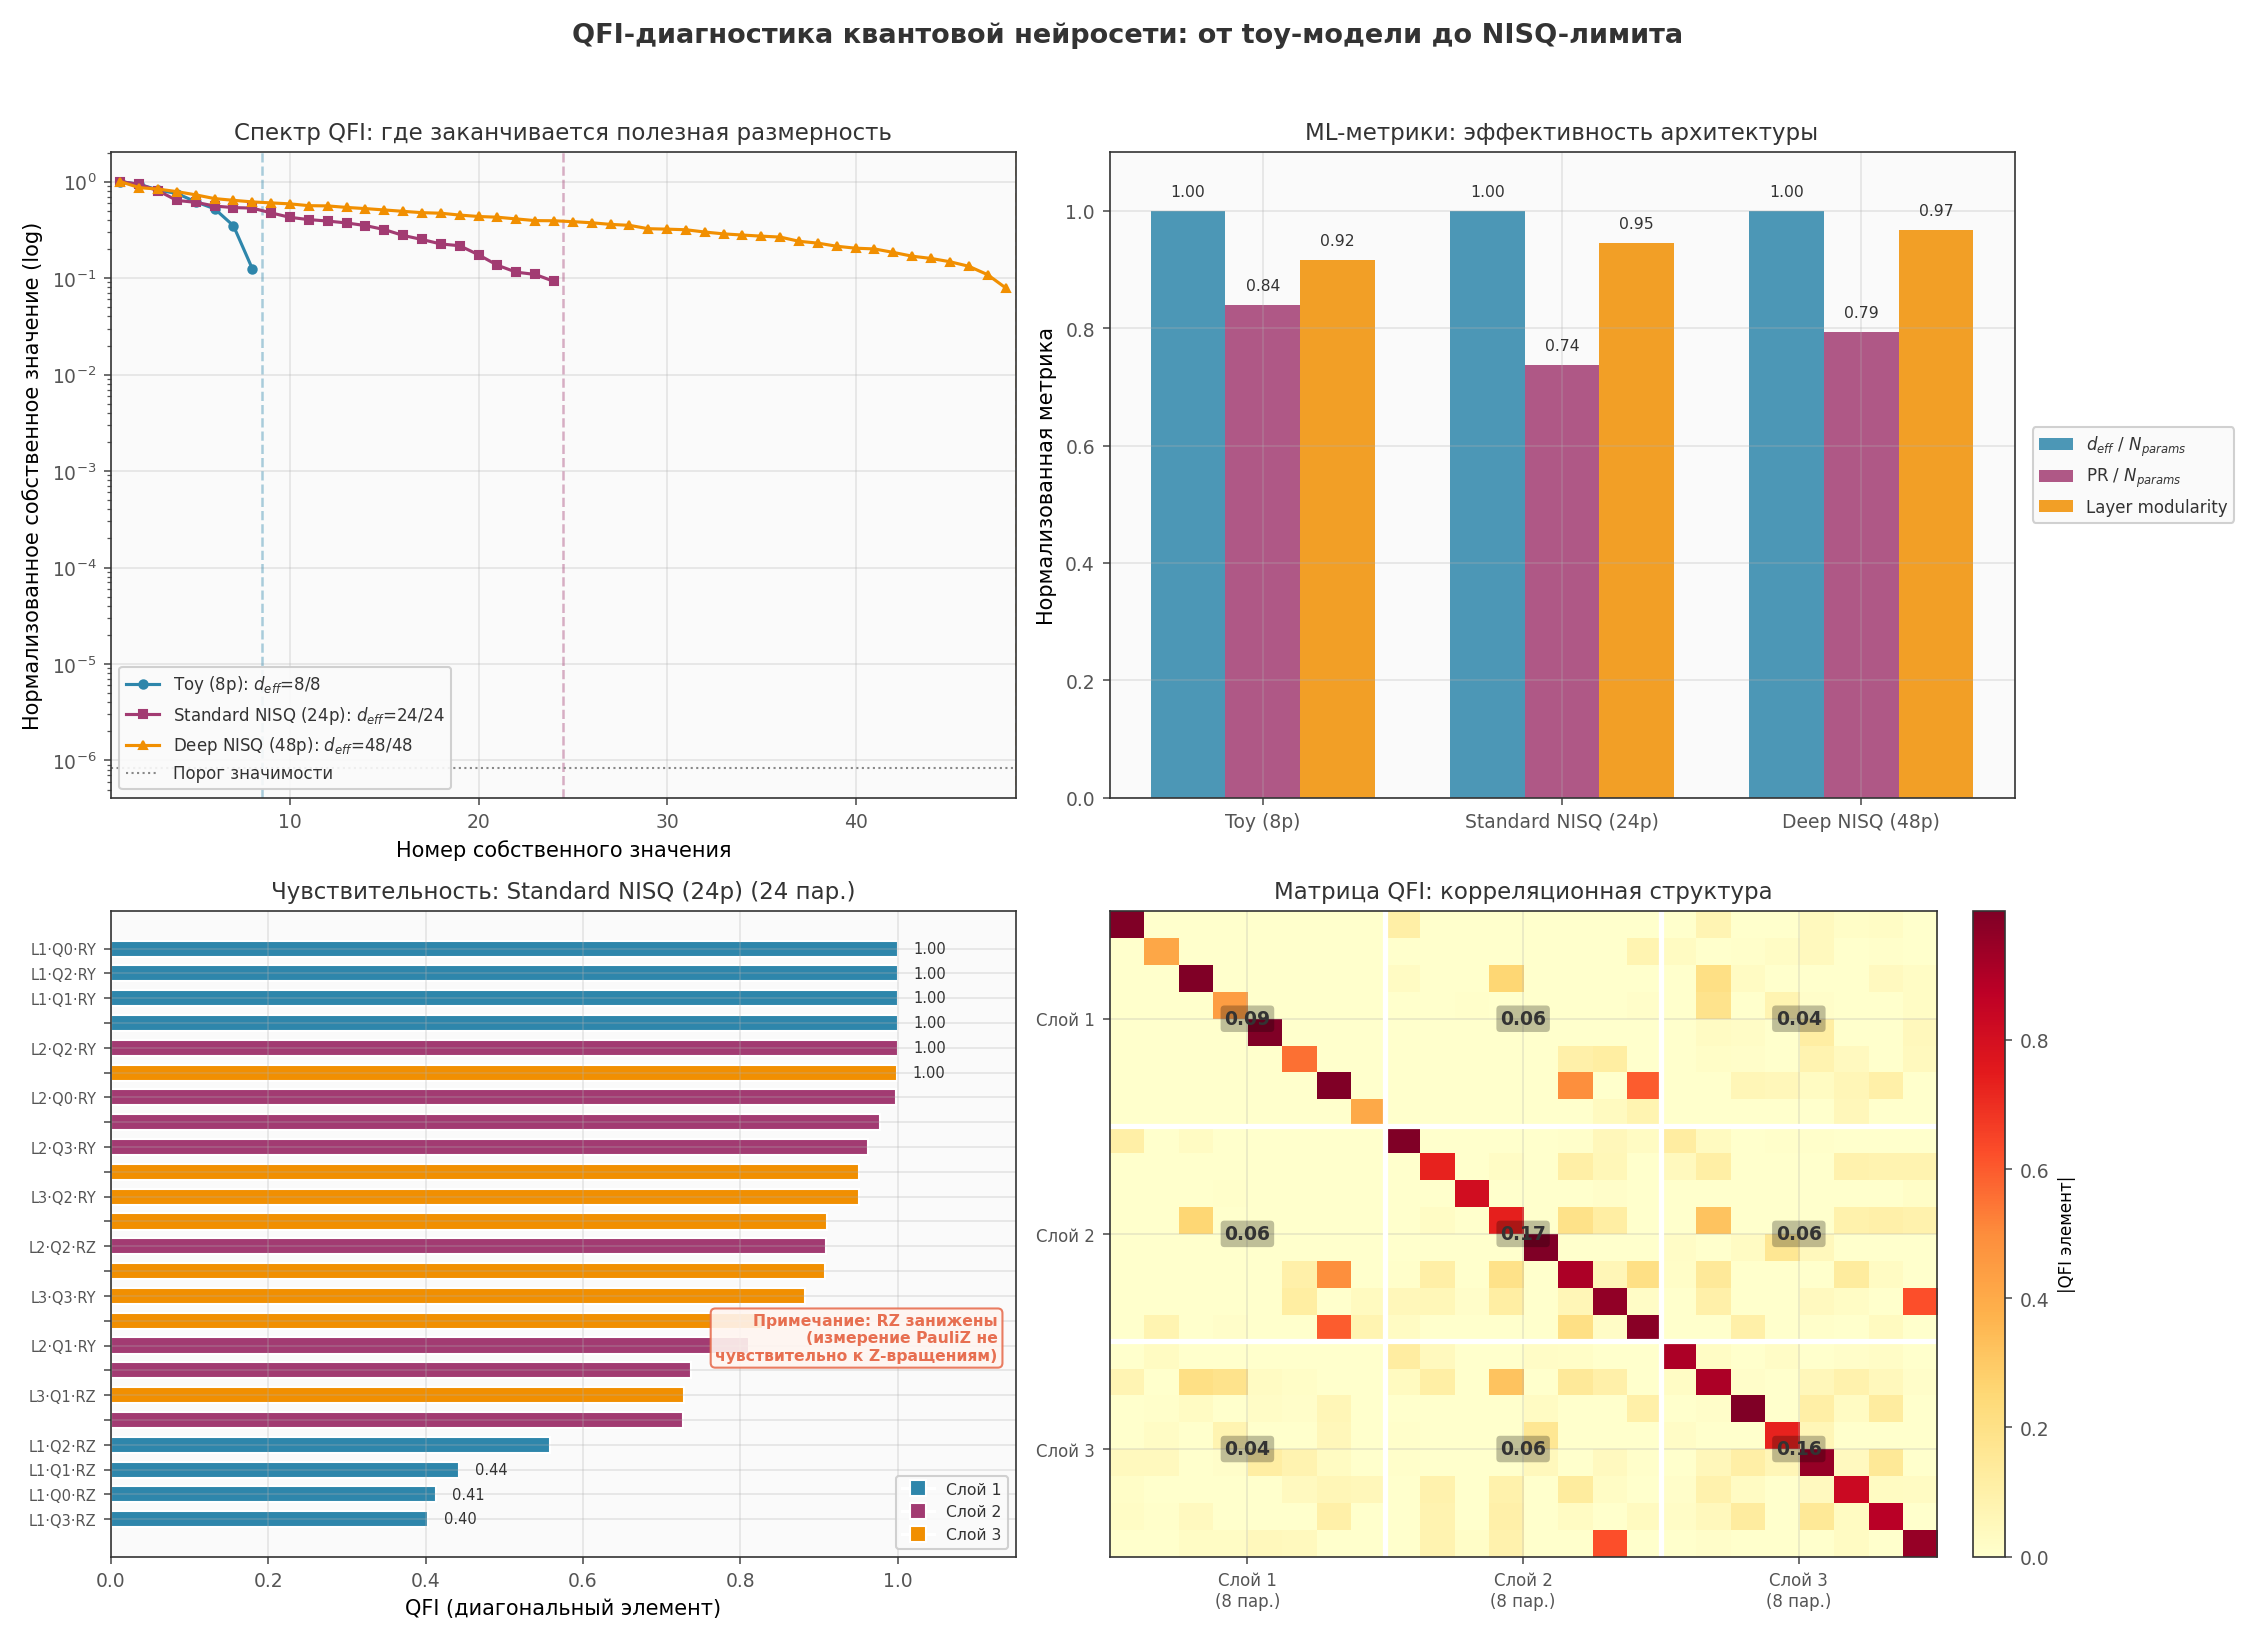

[✓] Сохранено: figures/qfi_ml_diagnostics.png

СКАНИРОВАНИЕ ГЛУБИНЫ (изолируем эффект числа слоев)

СКАНИРОВАНИЕ ГЛУБИНЫ (фиксировано: 4 кубита)
| Слоёв | Параметров | Средняя чувствительность | Прирост к пред. |
|---|---|---|---|
| 1 | 8 | 0.727 | — |
| 2 | 16 | 0.809 | +11.2% |
| 3 | 24 | 0.837 | +3.5% |
| 4 | 32 | 0.864 | +3.2% |
| 6 | 48 | 0.886 | +2.6% |


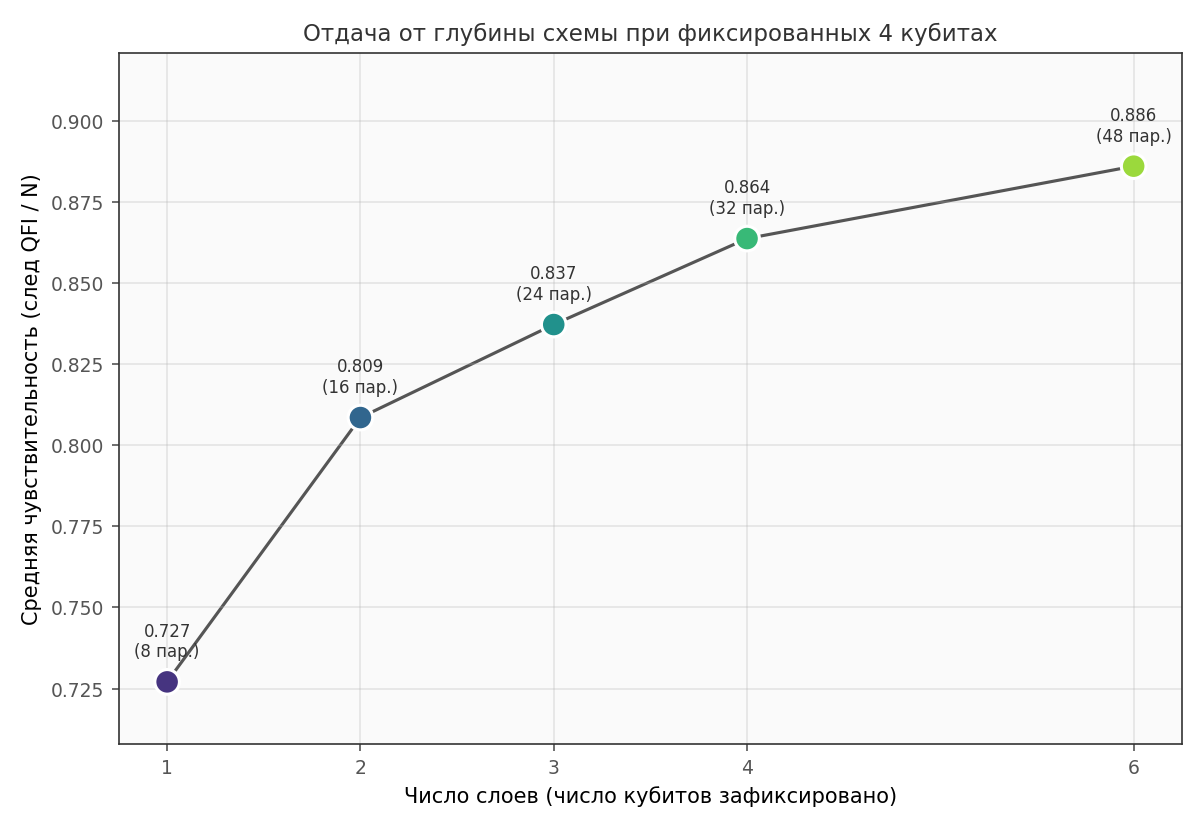

[✓] Сохранено: figures/qfi_depth_scan.png

КОРРЕЛЯЦИЯ С КЛАССИЧЕСКОЙ SVM + КВАНТОВАЯ РАЗВЕДКА
Корреляция Пирсона (QFI-чувствительность, расстояние до границы SVM): 0.552


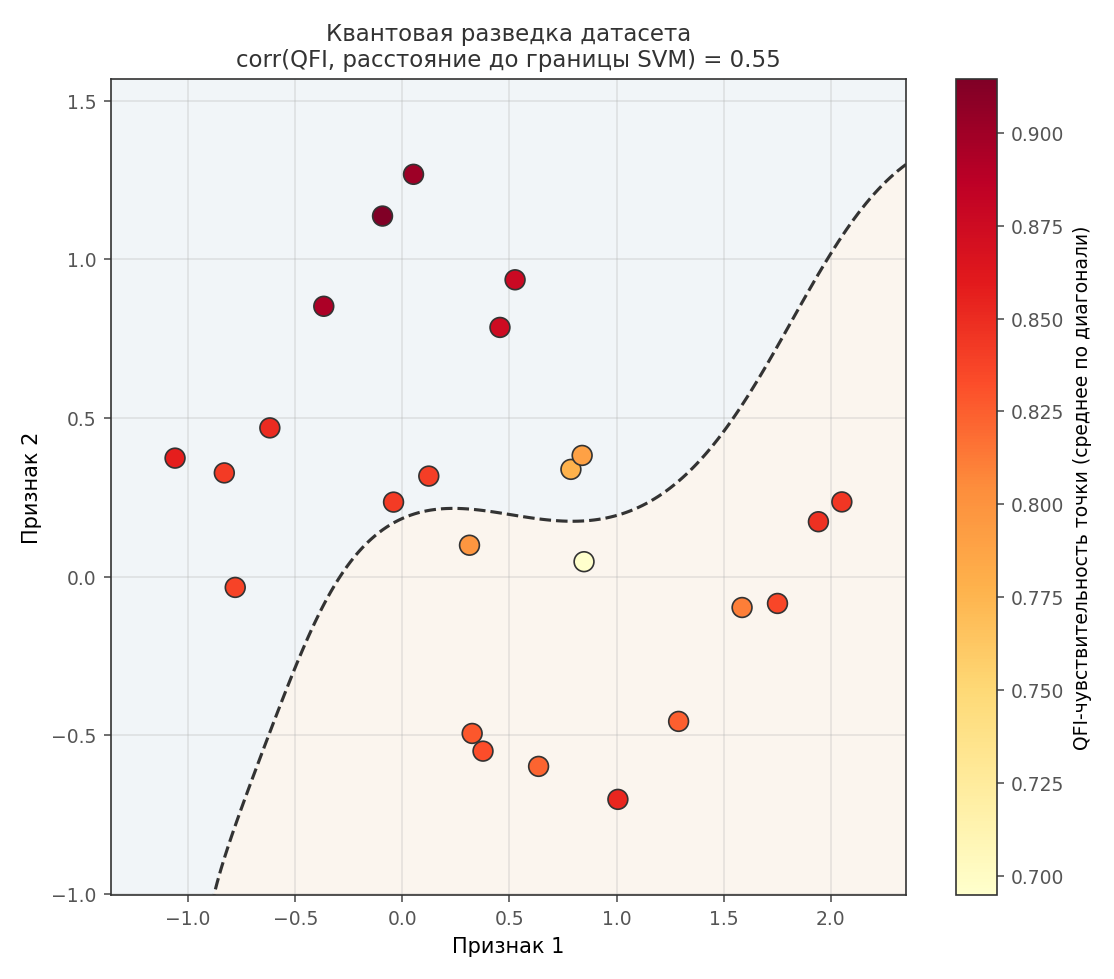

[✓] Сохранено: figures/qfi_reconnaissance.png


In [12]:
if __name__ == "__main__":
    SEED = 42

    # Датасет типичного для ML размера (см. раздел 1)
    X_scaled, y, X_raw = make_dataset(n_samples=24, noise=0.15, seed=SEED)

    # ── Основной эксперимент: Toy / Standard NISQ / Deep NISQ ──────────
    experiments = [
        ("Toy (8p)", 2, 2),
        ("Standard NISQ (24p)", 4, 3),
        ("Deep NISQ (48p)", 6, 4),
    ]

    results = []
    print("="*60)
    print("РАСЧЕТ QFI: три масштаба квантовой нейросети")
    print("="*60)
    for name, nq, nl in experiments:
        print(f"\n>>> {name}: {nq} кубитов × {nl} слоя...")
        m = run_experiment(name, nq, nl, X_scaled, seed=SEED)
        results.append(m)
        print(f"    Параметров: {m['n_params']} | "
              f"eff_dim: {m['eff_dim']} ({m['eff_dim_ratio']:.0%}) | "
              f"Spectral gap: {m['spectral_gap']:.1f} | "
              f"PR/N: {m['pr_ratio']:.2f} | "
              f"Cross-layer: {m['cross_layer_corr']:.3f} | "
              f"BP риск: {m['bp_risk']}")

    print_markdown_table(results)

    print("\n" + "="*60)
    print("ПОСТРОЕНИЕ ОСНОВНОЙ ФИГУРЫ")
    print("="*60)
    plot_article_figure(results, "figures/qfi_ml_diagnostics.png")

    # ── Честное сравнение глубины: фиксированные 4 кубита ──────────────
    print("\n" + "="*60)
    print("СКАНИРОВАНИЕ ГЛУБИНЫ (изолируем эффект числа слоев)")
    print("="*60)
    DEPTH_QUBITS = 4
    depth_results = run_depth_scan(DEPTH_QUBITS, [1, 2, 3, 4, 6], X_scaled, seed=SEED)
    print_depth_scan_table(depth_results, DEPTH_QUBITS)
    plot_depth_scan_figure(depth_results, DEPTH_QUBITS, "figures/qfi_depth_scan.png")

    # ── SVM-корреляция + квантовая разведка датасета ────────────────────
    print("\n" + "="*60)
    print("КОРРЕЛЯЦИЯ С КЛАССИЧЕСКОЙ SVM + КВАНТОВАЯ РАЗВЕДКА")
    print("="*60)
    svm_result = run_svm_correlation(X_scaled, y, n_qubits=4, n_layers=3, seed=SEED)
    print(f"Корреляция Пирсона (QFI-чувствительность, расстояние до границы SVM): "
          f"{svm_result['correlation']:.3f}")
    plot_reconnaissance_figure(X_raw, y, svm_result, "figures/qfi_reconnaissance.png")